In [134]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
# Load the dataset from your Excel file
df = pd.read_csv("../data/Solar_Flare_dataset_final.csv")
# Assuming your date column is named 'Date', convert it to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Set the 'Date' column as the index of the DataFrame
df.set_index('Date', inplace=True)

# Sort the DataFrame by date to ensure chronological order
df.sort_index(inplace=True)

print("Dataset loaded and indexed by date:")
print(df.head())
print("\nData Types:")
print(df.info())

Dataset loaded and indexed by date:
            Sunspot Number  Sunspot Area  Radio Flux 10.7 cm  Avg Xray Flux  \
Date                                                                          
2011-01-01              65           350                  91   1.653609e-07   
2011-01-02              38           260                  91   1.483776e-07   
2011-01-03              51           320                  92   1.681458e-07   
2011-01-04              54           360                  91   1.836410e-07   
2011-01-05              50           250                  88   1.151406e-07   

            Bkgd Xray Flux Flare Class  
Date                                    
2011-01-01    1.216868e-07           0  
2011-01-02    1.048219e-07           0  
2011-01-03    1.035273e-07           0  
2011-01-04    1.254856e-07           0  
2011-01-05    9.895133e-08           0  

Data Types:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5114 entries, 2011-01-01 to 2024-12-31
Data columns (tota

In [136]:
# --- 1. Rolling Window Statistics ---
window_size = 7  # You can experiment with values like 3, 7, or 14

# Rolling means
df['sunspot_area_mean_7d'] = df['Sunspot Area'].rolling(window=window_size).mean()
df['radio_flux_mean_7d'] = df['Radio Flux 10.7 cm'].rolling(window=window_size).mean()

# Rolling standard deviation (volatility)
df['xray_flux_std_7d'] = df['Avg Xray Flux'].rolling(window=window_size).std()
df['sunspot_num_std_7d'] = df['Sunspot Number'].rolling(window=window_size).std()

# Rolling max
df['sunspot_area_max_7d'] = df['Sunspot Area'].rolling(window=window_size).max()


# --- 2. Rate of Change (Differencing) ---
# 1-day change for key parameters
df['sunspot_area_change_1d'] = df['Sunspot Area'].diff(periods=1)
df['radio_flux_change_1d'] = df['Radio Flux 10.7 cm'].diff(periods=1)
df['bg_xray_flux_change_1d'] = df['Bkgd Xray Flux'].diff(periods=1)


# --- 3. Exponentially Weighted Moving Average (EWMA) ---
span_size = 7 # The 'span' is similar to the window size

df['sunspot_num_ewm_7d'] = df['Sunspot Number'].ewm(span=span_size).mean()
df['bg_xray_flux_ewm_7d'] = df['Bkgd Xray Flux'].ewm(span=span_size).mean()


# --- 4. Clean Up ---
# Drop rows with NaN values created by the rolling/differencing operations
df.dropna(inplace=True)

print("Feature engineering complete. New features added.")
print(df.head())

Feature engineering complete. New features added.
            Sunspot Number  Sunspot Area  Radio Flux 10.7 cm  Avg Xray Flux  \
Date                                                                          
2011-01-07              52           170                  86   1.104191e-07   
2011-01-08              52           180                  85   9.344132e-08   
2011-01-09              50           150                  83   8.870552e-08   
2011-01-10              35           140                  83   1.166270e-07   
2011-01-11              26           130                  83   9.417571e-08   

            Bkgd Xray Flux Flare Class  sunspot_area_mean_7d  \
Date                                                           
2011-01-07    8.962088e-08           0            277.142857   
2011-01-08    8.118010e-08           0            252.857143   
2011-01-09    8.136462e-08           0            237.142857   
2011-01-10    8.160598e-08           0            211.428571   
2011-01-11  

In [137]:


# 1. Load Data and Define X and y
# Start with your original, un-windowed DataFrame 'df'
X = df.drop('Flare Class', axis=1)
y = df['Flare Class']

# 2. Encode Target Variable
# It's fine to encode the entire 'y' series at once
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y.astype(str))


# 3. Chronological Split (DO THIS FIRST)
# Split your original X and your fully encoded y
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y_encoded[:split_index], y_encoded[split_index:]


# 4. Scale Features (Fit on Train, Transform Both)
scaler = StandardScaler()
# Note: fit_transform returns a numpy array, so we wrap it in a DataFrame
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X.columns)


# 5. Create Lagged Features (Apply to both sets)
def create_lagged_features(data, lag=7):
    df_lagged = data.copy() # Use .copy() to avoid SettingWithCopyWarning
    for i in range(1, lag + 1):
        df_lagged = pd.concat([df_lagged, data.shift(i).add_suffix(f'_lag{i}')], axis=1)
    df_lagged.dropna(inplace=True)
    return df_lagged

X_train_windowed = create_lagged_features(X_train_scaled, lag=7)
X_test_windowed = create_lagged_features(X_test_scaled, lag=7)


# 6. Align y (DO THIS LAST)
# Align y_train with the now-windowed X_train_windowed
y_train_aligned = y_train[len(y_train) - len(X_train_windowed):]
# Align y_test with the now-windowed X_test_windowed
y_test_aligned = y_test[len(y_test) - len(X_test_windowed):]


# 7. Final Check
print("Shape of windowed training features:", X_train_windowed.shape)
print("Shape of aligned training target:", y_train_aligned.shape)
print("\nShape of windowed test features:", X_test_windowed.shape)
print("Shape of aligned test target:", y_test_aligned.shape)

Shape of windowed training features: (4079, 120)
Shape of aligned training target: (4079,)

Shape of windowed test features: (1015, 120)
Shape of aligned test target: (1015,)


In [138]:
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb

# Calculate weights based on the final aligned training labels
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_aligned
)

# Initialize your XGBoost model
model = xgb.XGBClassifier(
    objective='multi:softmax',
    eval_metric='mlogloss'
)

# Train the model, passing in the calculated sample weights
print("\n--- Training Model with Sample Weights ---")
model.fit(
    X_train_windowed, 
    y_train_aligned,
    sample_weight=sample_weights # Pass the weights here
)


--- Training Model with Sample Weights ---


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [139]:
# Calculate weights to handle the imbalanced classes in the training data
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_aligned
)

In [140]:
# Initialize the XGBoost model for multi-class classification
# Key parameters:
# objective='multi:softprob': outputs probabilities for each class
# eval_metric='mlogloss': evaluation metric for multi-class classification
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    n_estimators=400,        # Number of trees
    learning_rate=0.1,
    max_depth=12,
    random_state=42
)

# Train the model on the windowed training data with sample weights
xgb_model.fit(
    X_train_windowed, 
    y_train_aligned, 
    sample_weight=sample_weights,
    verbose=True # Set to True to see training progress
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=12, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [141]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test_windowed)

Model Accuracy: 0.761576354679803

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.73      0.78       528
           M       0.71      0.83      0.76       466
           X       0.20      0.10      0.13        21

    accuracy                           0.76      1015
   macro avg       0.58      0.55      0.56      1015
weighted avg       0.76      0.76      0.76      1015


--- True Skill Statistic (TSS) ---
TSS for class '0': 0.5771
TSS for class 'M': 0.5366
TSS for class 'X': 0.0872

--- Generating Visualizations ---


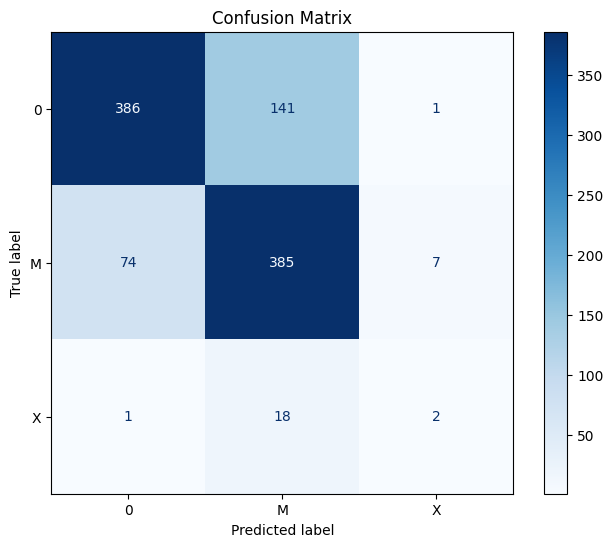

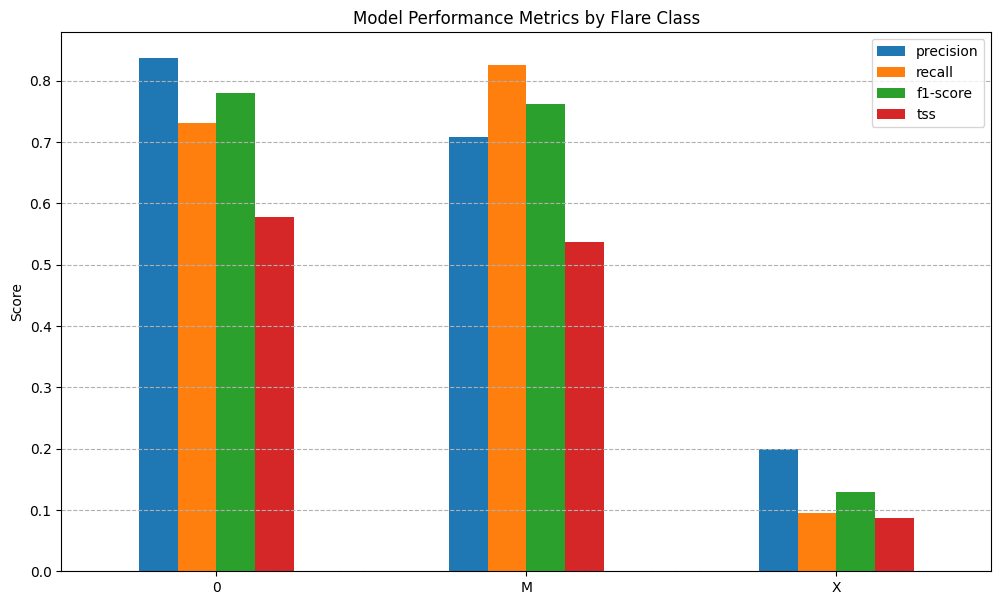

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# --- Your existing text-based reports ---
target_names = label_encoder.classes_

print("Model Accuracy:", accuracy_score(y_test_aligned, y_pred))
print("\n" + "="*60)
print("Classification Report:")
print(classification_report(y_test_aligned, y_pred, target_names=target_names))
print("="*60 + "\n")


# --- NEW: Calculate True Skill Statistic (TSS) for each class ---
print("--- True Skill Statistic (TSS) ---")
cm = confusion_matrix(y_test_aligned, y_pred)
tss_scores = {}

for i in range(len(target_names)):
    # Deconstruct the confusion matrix for each class
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fp + fn)

    # Calculate True Positive Rate (TPR) and False Positive Rate (FPR)
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    # Calculate TSS
    tss = tpr - fpr
    tss_scores[target_names[i]] = tss
    print(f"TSS for class '{target_names[i]}': {tss:.4f}")


# --- NEW: Graphical Visualizations (including TSS) ---
print("\n--- Generating Visualizations ---")

# 1. Graphical Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix")
plt.show()

# 2. Bar Chart of Performance Metrics (including TSS)
report_dict = classification_report(
    y_test_aligned,
    y_pred,
    target_names=target_names,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose()

# Add the TSS scores to the report DataFrame
report_df['tss'] = pd.Series(tss_scores)

# Remove summary rows to only plot the classes
report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'])

# Plot the key metrics
report_df[['precision', 'recall', 'f1-score', 'tss']].plot(kind='bar', figsize=(12, 7))
plt.title('Model Performance Metrics by Flare Class')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.show()